### Contents

1 Import libraries and dataset  
2 Inspect and prepare data  
3 Decomposition  
4 Stationarity

### 1 Import libraries and dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
import warnings

warnings.filterwarnings("ignore") # Disable deprecation warnings

plt.style.use('fivethirtyeight')

In [3]:
path = r"C:\Users\cathe\OneDrive\Data Analysis\2 6 Schools in England and Wales\02 Data"

In [4]:
df = pd.read_csv(os.path.join(path, "Original Data", "Av inspection results.csv"))

### 2 Inspect and prepare data

In [6]:
df.head()

,Date,Average inspection result
0,2020-01-01,1.9783
1,2020-02-01,1.9779
2,2020-03-01,1.9792
3,2020-04-01,1.9791
4,2020-05-01,1.9790


In [7]:
# Transform date column into index

from datetime import datetime

df['datetime'] = pd.to_datetime(df['Date']) # Create a datetime column from "Date.""
df = df.set_index('datetime') # Set the datetime as the index of the dataframe.
df.drop(['Date'], axis=1, inplace=True) # Drop the "Date" column.
df.head()

,Average inspection result
datetime,
2020-01-01,1.9783
2020-02-01,1.9779
2020-03-01,1.9792
2020-04-01,1.9791
2020-05-01,1.9790


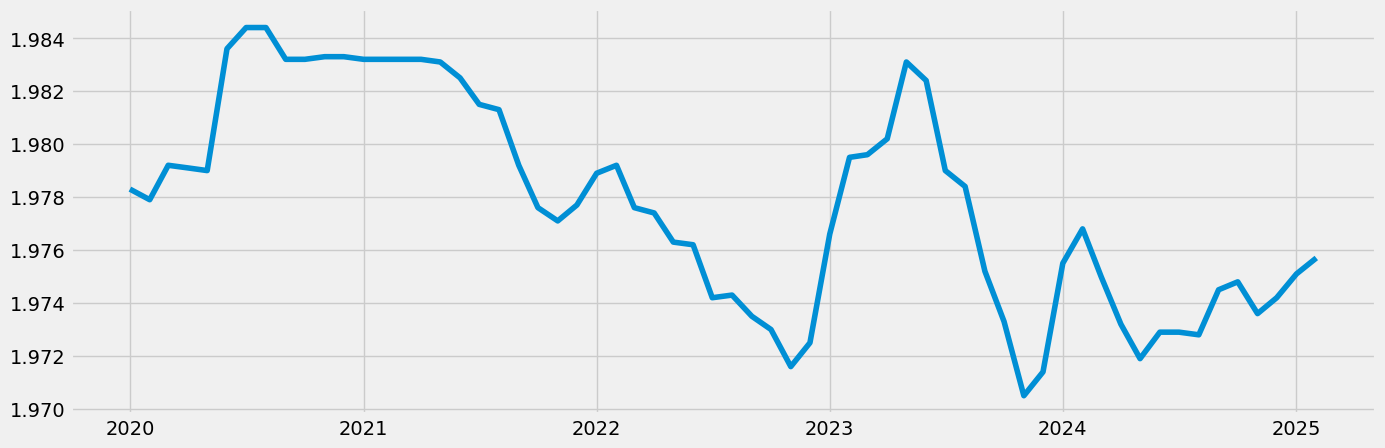

In [8]:
# Plot the data

plt.figure(figsize=(15,5), dpi=100) 
plt.plot(df)

### 3 Decomposition

In [10]:
# Decompose the time series using an additive model

decomposition = sm.tsa.seasonal_decompose(df, model='additive')

In [11]:
from pylab import rcParams

rcParams['figure.figsize'] = 18, 7

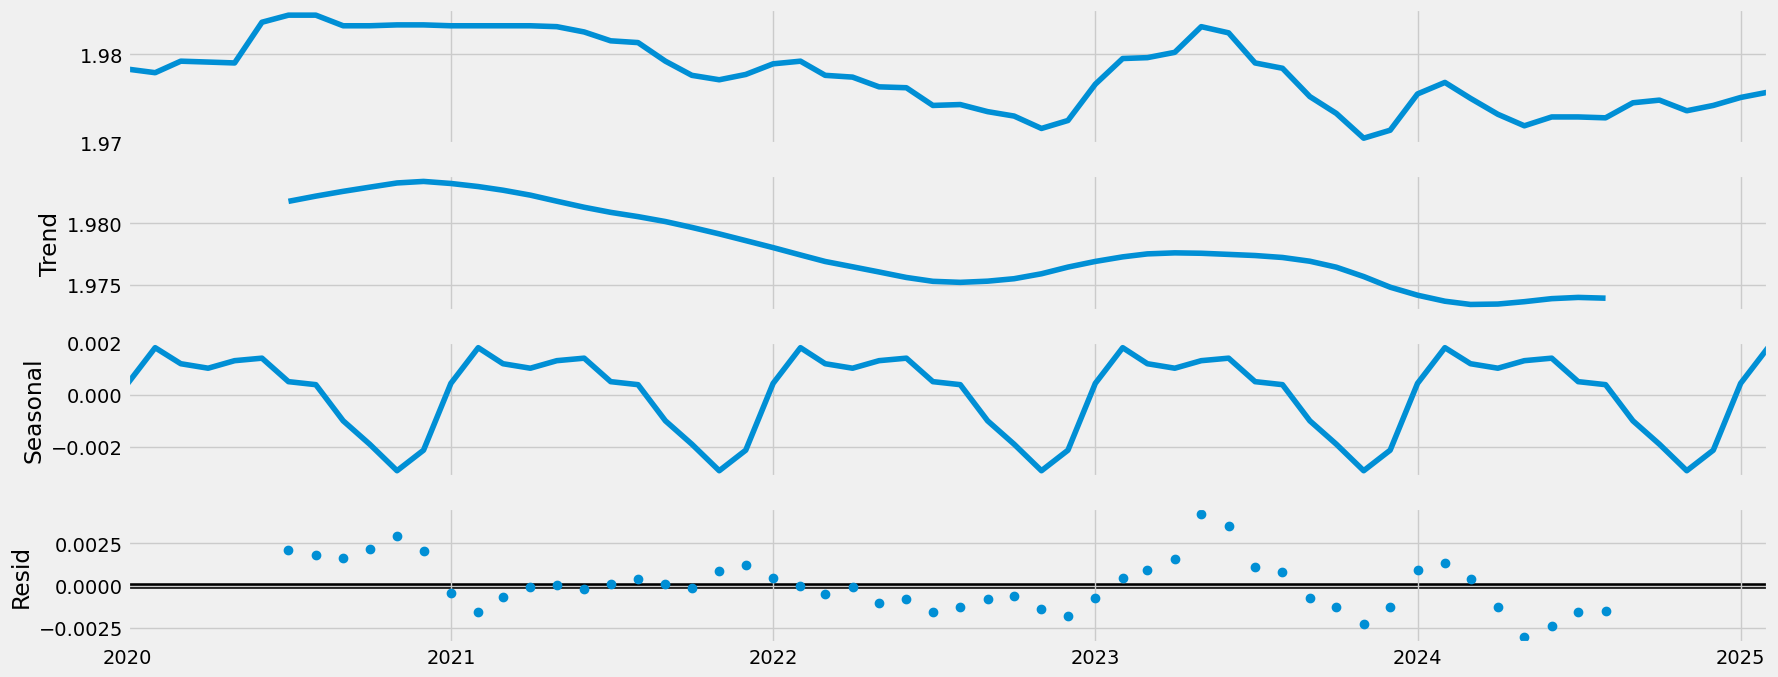

In [12]:
# Plot the decomposed components

decomposition.plot()
plt.show()

Comments:
- Trend: inspection results have been decreasing over the past five years, but since 1 is the top grade, this actually means an improvement in judgements of schools in England
- Seasonality: slightly worse (higher) results from January to August and slightly better grades (lower numbers) in the remaining months of the year
- Noise: more noise at the end of 2020 (possibly due to Covid) and around April-May 2023

### 4 Stationarity

Null hypothesis: there is a unit root ie data is not stationary  
Alternative hypothesis: there is no unit root ie data is stationary

In [28]:
# Dickey-Fuller test

from statsmodels.tsa.stattools import adfuller

def dickey_fuller(timeseries):
    print ('Dickey-Fuller Stationarity test:')
    test = adfuller(timeseries, autolag='AIC')
    result = pd.Series(test[0:4], index=['Test Statistic','p-value','Number of Lags Used','Number of Observations Used'])
    for key,value in test[4].items():
       result['Critical Value (%s)'%key] = value
    print (result)

dickey_fuller(df['Average inspection result'])

Dickey-Fuller Stationarity test:
Test Statistic                 -2.229865
p-value                         0.195585
Number of Lags Used             1.000000
Number of Observations Used    60.000000
Critical Value (1%)            -3.544369
Critical Value (5%)            -2.911073
Critical Value (10%)           -2.593190
dtype: float64


Test statistic is bigger than all three critical values, and p-value is greater than 0.05  
Therefore we cannot reject the null hypothesis

In [33]:
# Differencing

data_diff = df - df.shift(1)
data_diff.dropna(inplace = True)

In [35]:
data_diff.head()

,Average inspection result
datetime,
2020-02-01,-0.0004
2020-03-01,0.0013
2020-04-01,-0.0001
2020-05-01,-0.0001
2020-06-01,0.0046


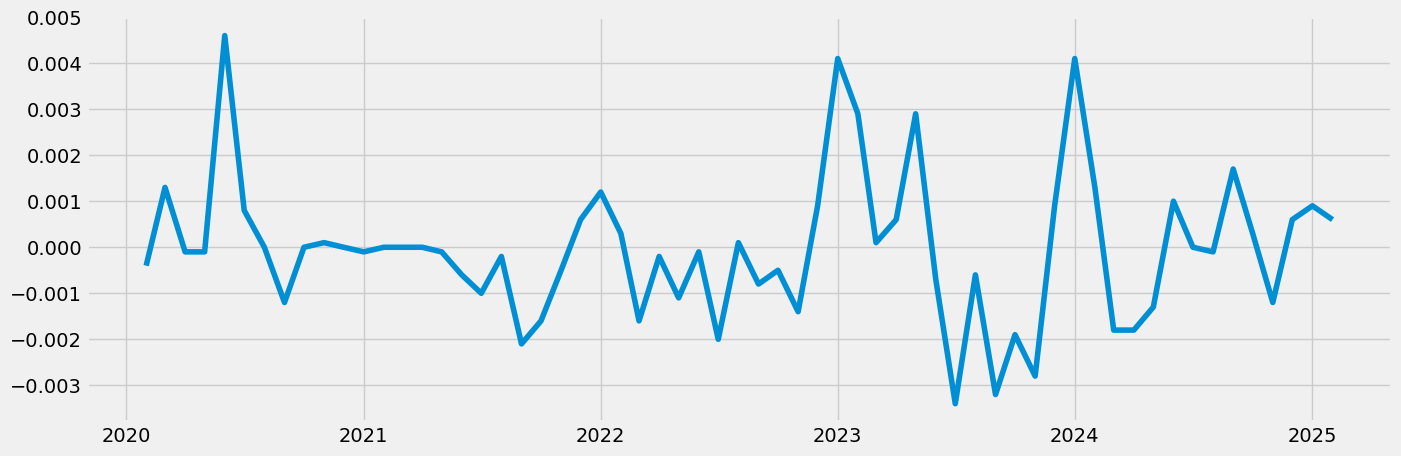

In [37]:
# Check out what the differencing did to the time-series curve

plt.figure(figsize=(15,5), dpi=100)
plt.plot(data_diff)

In [39]:
# Repeat Dickey-Fuller test

dickey_fuller(data_diff)

Dickey-Fuller Stationarity test:
Test Statistic                 -5.264868
p-value                         0.000006
Number of Lags Used             1.000000
Number of Observations Used    59.000000
Critical Value (1%)            -3.546395
Critical Value (5%)            -2.911939
Critical Value (10%)           -2.593652
dtype: float64


P-value now way below 0.05 - reject null hypothesis this time and conclude that time series is highly likely to be stationary.

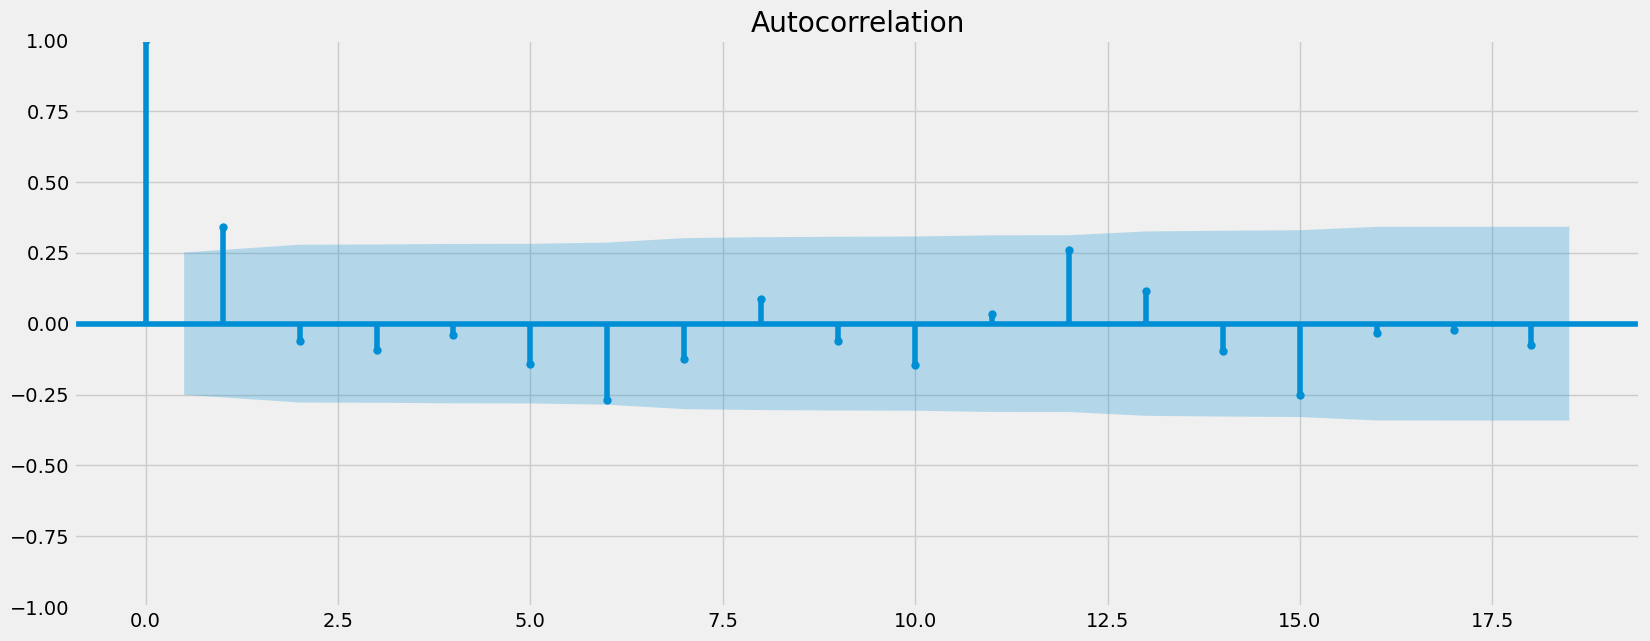

In [42]:
# Check autocorrelations

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(data_diff)
plt.show()

Only 2 significant lags, confirming the stationarity of data_diff.